In [2]:
%matplotlib widget
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import hilbert, butter, filtfilt, windows
from scipy.ndimage import uniform_filter1d

plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)

DATA_DIR = os.path.expanduser(
    "~/eedm_jml/daqAnalysisAndExperiments/MOT_fill/data"
)


def load_trace(fname=None, data_dir=DATA_DIR):
    """Load an npz trace. If fname is None, offer the most recent file."""
    if fname is None:
        files = sorted(glob.glob(os.path.join(data_dir, "*.npz")),
                       key=os.path.getmtime)
        if not files:
            raise FileNotFoundError(f"No .npz files in {data_dir}")
        fname = files[-1]
        ans = input(f"No file given. Load most recent?\n  {os.path.basename(fname)}\n[y/n] ")
        if ans.strip().lower() not in ("y", "yes", ""):
            raise RuntimeError("Aborted; pass fname explicitly.")
    elif not os.path.isabs(fname):
        fname = os.path.join(data_dir, fname)

    d = np.load(fname)
    times, volts = d["times"], d["voltages"]
    sr = float(d["sample_rate"])
    print(f"{os.path.basename(fname)}: {len(volts)/1e6:.3f} Mpts @ {sr/1e6:.3f} MSa/s, "
          f"{(times[-1]-times[0])*1e3:.2f} ms span")
    return times, volts, sr, fname

motFill_70dBGain_50OhmOnPD_sideLock_20260727_174407.npz: 1.000 Mpts @ 0.020 MSa/s, 49999.95 ms span


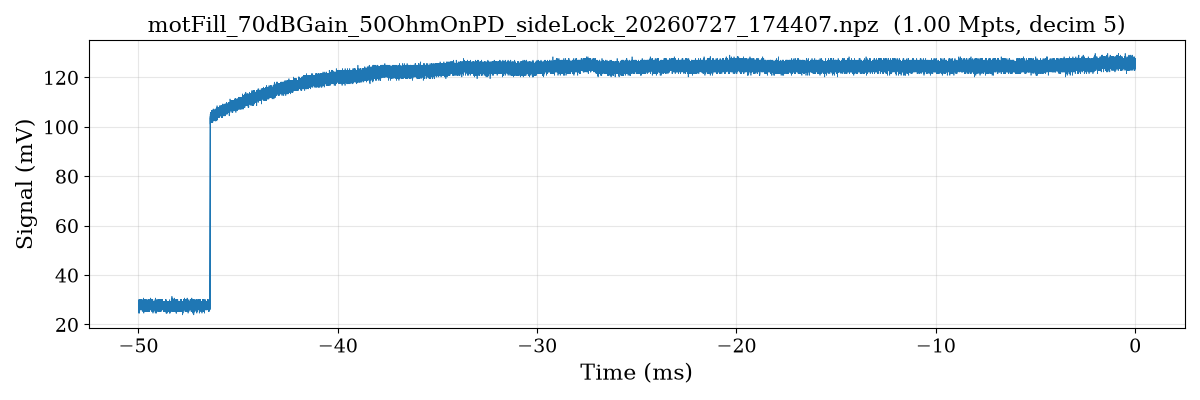

In [3]:
FNAME = None          # None -> prompt for most recent
MAX_PLOT_PTS = 200_000

times, voltages, sr, fname = load_trace(FNAME)

decim = max(1, len(voltages) // MAX_PLOT_PTS)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(times[::decim] , voltages[::decim] * 1e3, lw=0.5)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Signal (mV)")
ax.set_title(f"{os.path.basename(fname)}  ({len(voltages)/1e6:.2f} Mpts, decim {decim})")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

t_open     = -46.4049 s
b_closed   =   27.680 +- 0.903 mV  (rms)
b_open     =  103.532 +- 0.055 mV
dV         =   21.118 +- 0.054 mV
tau        =   4.2694 +- 0.0172 s
plateau    =  124.649 mV
resid rms  = 1.083 mV


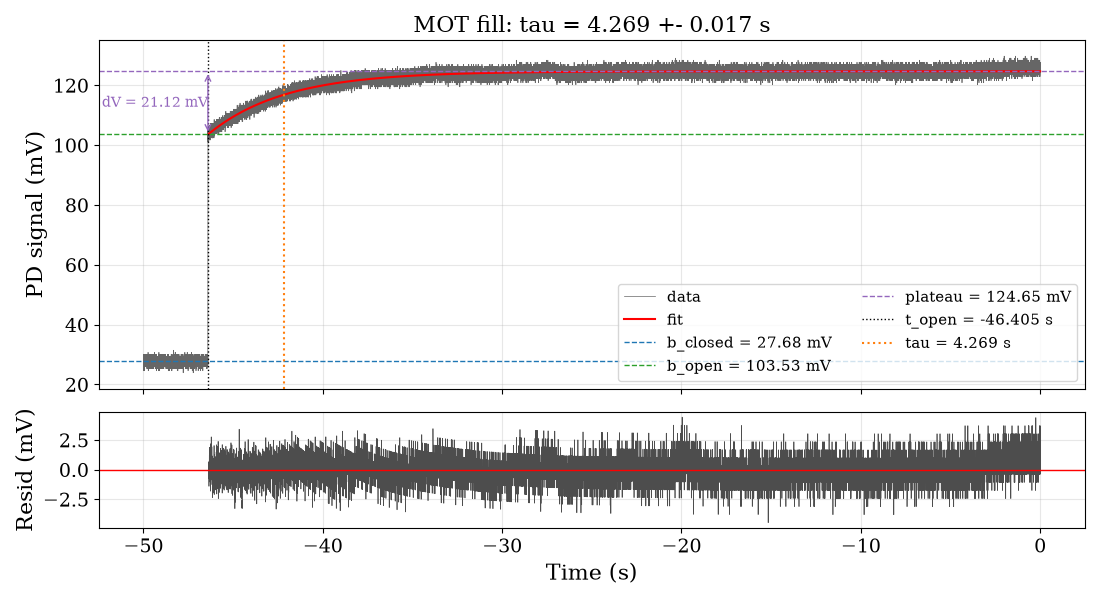

In [4]:
# Expected trace: flat shutter-closed background for a few seconds, a sharp step
# up to the laser-scatter background when the shutter opens, then an exponential
# MOT fill to plateau. Exactly one edge; fill runs to the end of the record.

FIT_DECIM    = 50       # decimation for the fit (speed / noise averaging)
EDGE_GUARD   = 0.05     # s skipped after the edge (shutter transit)
BKG_GUARD    = 0.20     # s before the edge excluded from closed-background mean
MAX_PLOT_PTS = 200_000

def fill_model(dt, b_open, dv, tau):
    return b_open + dv * (1 - np.exp(-dt / tau))

n = len(voltages)
v_lo = np.median(voltages[:n // 50])
v_hi = np.median(voltages[-n // 20:])
i_open = np.argmax(voltages > 0.5 * (v_lo + v_hi))
t_open = times[i_open]

pre = voltages[times < t_open - BKG_GUARD]
b_closed, b_closed_err = pre.mean(), pre.std()

m = times > t_open + EDGE_GUARD
t_fit, v_fit = times[m][::FIT_DECIM], voltages[m][::FIT_DECIM]
popt, pcov = curve_fit(fill_model, t_fit - t_open, v_fit,
                       p0=[v_fit[0], v_hi - v_fit[0], 1.0])
b_open, dv, tau = popt
e_open, e_dv, e_tau = np.sqrt(np.diag(pcov))
resid = v_fit - fill_model(t_fit - t_open, *popt)

print(f"t_open     = {t_open:.4f} s")
print(f"b_closed   = {b_closed*1e3:8.3f} +- {b_closed_err*1e3:.3f} mV  (rms)")
print(f"b_open     = {b_open*1e3:8.3f} +- {e_open*1e3:.3f} mV")
print(f"dV         = {dv*1e3:8.3f} +- {e_dv*1e3:.3f} mV")
print(f"tau        = {tau:8.4f} +- {e_tau:.4f} s")
print(f"plateau    = {(b_open+dv)*1e3:8.3f} mV")
print(f"resid rms  = {resid.std()*1e3:.3f} mV")

dec = max(1, n // MAX_PLOT_PTS)

plt.close('all')

fig, (ax, axr) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
ax.plot(times[::dec], voltages[::dec] * 1e3, lw=0.5, color="0.4", label="data")
ax.plot(t_fit, fill_model(t_fit - t_open, *popt) * 1e3, "r-", lw=1.5, label="fit")
ax.axhline(b_closed*1e3, color="C0", ls="--", lw=1, label=f"b_closed = {b_closed*1e3:.2f} mV")
ax.axhline(b_open*1e3, color="C2", ls="--", lw=1, label=f"b_open = {b_open*1e3:.2f} mV")
ax.axhline((b_open+dv)*1e3, color="C4", ls="--", lw=1, label=f"plateau = {(b_open+dv)*1e3:.2f} mV")
ax.axvline(t_open, color="k", ls=":", lw=1, label=f"t_open = {t_open:.3f} s")
ax.axvline(t_open+tau, color="C1", ls=":", lw=1.5, label=f"tau = {tau:.3f} s")
ax.annotate("", xy=(t_open, b_open*1e3), xytext=(t_open, (b_open+dv)*1e3),
            arrowprops=dict(arrowstyle="<->", color="C4"))
ax.text(t_open, (b_open+dv/2)*1e3, f"  dV = {dv*1e3:.2f} mV", color="C4", va="center", ha = 'right')
ax.set_ylabel("PD signal (mV)")
ax.set_title(f"MOT fill: tau = {tau:.3f} +- {e_tau:.3f} s")
ax.legend(loc="lower right", fontsize=11, ncol=2)
ax.grid(True, alpha=0.3)

axr.plot(t_fit, resid * 1e3, lw=0.5, color="0.3")
axr.axhline(0, color="r", lw=1)
axr.set_xlabel("Time (s)")
axr.set_ylabel("Resid (mV)")
axr.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [47]:
# --- constants ---
h, c = 6.62607015e-34, 2.99792458e8
lam   = 852.34727582e-9
Gamma = 2*np.pi*5.2227e6

# --- setup ---
G_TIA   = 2.35e6      # V/A (50 ohm value)
RESP    = 0.55        # A/W at 852 nm
A_PD    = (10e-3)**2  # m^2
D_PD    = .200 # m
T_OPT   = 1         # viewport * filter transmission
I_TOT   = 9        # mW/cm^2, summed over all 6 passes
I_SAT   = 2.71        # mW/cm^2, isotropic-polarization value
DELTA   = .15*Gamma        # rad/s, cooling detuning (negative)

eta   = (A_PD/(4*np.pi*D_PD**2)) * T_OPT
P_tot = (dv/G_TIA/RESP) / eta
R_tot = P_tot*lam/(h*c)

s = I_TOT/I_SAT
R_atom = (Gamma/2) * s/(1 + s + (2*DELTA/Gamma)**2)
N = R_tot/R_atom
print(f"eta_geo = {eta:.3e}, P_tot = {P_tot*1e9:.2f} nW, N = {N:.3e}")
print(f"R atom = {round(R_atom/1e6,3)} MHz")
print(f"s = {round(s,3)}")
print(N/dv)

eta_geo = 1.989e-04, P_tot = 82127.51 nW, N = 2.853e+07
R atom = 12.353 MHz
s = 3.321
1350831890.6250887
